In [1]:
!pip install mne
!pip install tensorflow
!pip install scikit-learn

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Madhav reddy 01.000.02 AGE 21  EC.edf to Madhav reddy 01.000.02 AGE 21  EC.edf


In [3]:
import mne

raw = mne.io.read_raw_edf(
    'Madhav reddy 01.000.02 AGE 21  EC.edf',
    preload=True
)

Extracting EDF parameters from Madhav reddy 01.000.02 AGE 21  EC.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 61183  =      0.000 ...   238.996 secs...


In [4]:
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1-LE, EEG Fp2-LE, EEG F3-LE, EEG F4-LE, EEG C3-LE, EEG ...
 chs: 20 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2026-03-26 11:37:11 UTC
 nchan: 20
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Madhav, sex: 0, last_name: 14-FEB-2005>
>


Using matplotlib as 2D backend.


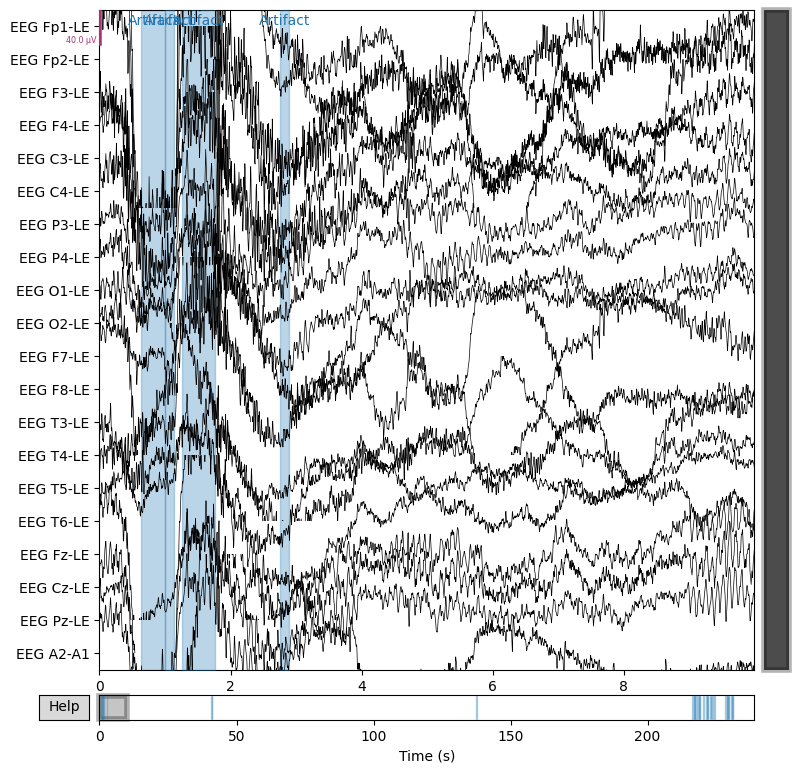

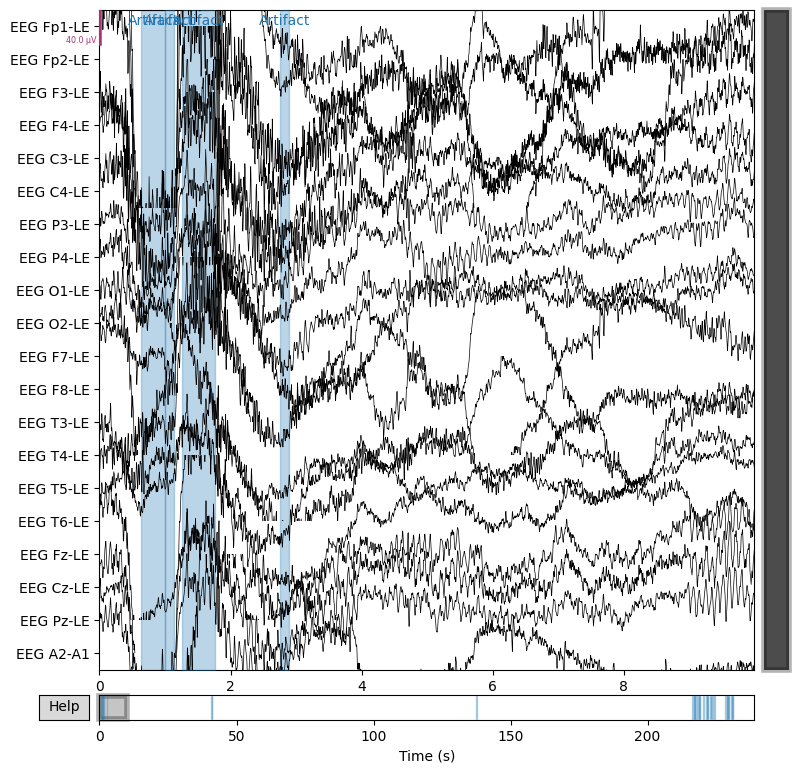

In [5]:
raw.plot()

In [6]:
raw.filter(0.5, 50)
raw.notch_filter(50)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband e

<RawEDF | Madhav reddy 01.000.02 AGE 21  EC.edf, 20 x 61184 (239.0 s), ~9.4 MiB, data loaded>

In [7]:
X = raw.get_data()
print(X.shape)

(20, 61184)


In [12]:
# STEP 8 — Transpose EEG Data

import numpy as np

# Extract EEG data from EDF file
X = raw.get_data()

# Print original shape
print("Original Shape:")
print(X.shape)

# Transpose data
X = X.T

# Print transposed shape
print("Transposed Shape:")
print(X.shape)

Original Shape:
(20, 61184)
Transposed Shape:
(61184, 20)


In [13]:
import numpy as np

y = np.random.randint(0, 2, size=X.shape[0])

In [35]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Normalize EEG data
scaler = StandardScaler()

X = scaler.fit_transform(X)

# -------------------------------
# Reduce dataset to 5000 samples
# -------------------------------

indices = np.random.choice(
    X.shape[0],
    5000,
    replace=False
)

X = X[indices]
y = y[indices]

print("Reduced X shape:", X.shape)
print("Reduced y shape:", y.shape)

Reduced X shape: (5000, 20)
Reduced y shape: (5000,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

cnn_model = Sequential()

cnn_model.add(
    Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu',
        input_shape=(X_train.shape[1], 1)
    )
)

cnn_model.add(
    MaxPooling1D(pool_size=2)
)

cnn_model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

cnn_model.add(Flatten())

cnn_model.add(
    Dense(128, activation='relu')
)

cnn_model.add(
    Dropout(0.5)
)

# Feature extraction layer
cnn_model.add(
    Dense(64, activation='relu', name='feature_layer')
)

# Final output layer
cnn_model.add(
    Dense(1, activation='sigmoid')
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [38]:
cnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.4962 - loss: 0.6943 - val_accuracy: 0.5086 - val_loss: 0.6931
Epoch 2/5
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4975 - loss: 0.6934 - val_accuracy: 0.5084 - val_loss: 0.6930
Epoch 3/5
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4991 - loss: 0.6933 - val_accuracy: 0.4932 - val_loss: 0.6934
Epoch 4/5
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5000 - loss: 0.6933 - val_accuracy: 0.4925 - val_loss: 0.6932
Epoch 5/5
1224/1224 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4987 - loss: 0.6932 - val_accuracy: 0.4926 - val_loss: 0.6932


In [39]:
from tensorflow.keras.models import Model

feature_extractor = Model(
    inputs=cnn_model.inputs,
    outputs=cnn_model.get_layer('feature_layer').output
)

In [40]:
train_features = feature_extractor.predict(X_train)

test_features = feature_extractor.predict(X_test)

print(train_features.shape)
print(test_features.shape)

1530/1530 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(48947, 64)
(12237, 64)


In [41]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='linear'
)

svm_model.fit(train_features, y_train)

SVC(kernel='linear')

In [42]:
y_pred = svm_model.predict(test_features)

In [43]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.4994688240581842

Classification Report:

              precision    recall  f1-score   support

           0       0.50      1.00      0.67      6104
           1       0.62      0.00      0.01      6133

    accuracy                           0.50     12237
   macro avg       0.56      0.50      0.34     12237
weighted avg       0.56      0.50      0.34     12237

